### Computing the Cost Matrices

In [1]:
import ot
import numpy as np

n_problems = 4  # nb problems/batch size
n_samples = 8  # nb samples
dim = 2  # nb dimensions

np.random.seed(0)
samples_source = np.random.randn(n_problems, n_samples, dim)
samples_target = samples_source + 0.1 * np.random.randn(n_problems, n_samples, dim)

# Naive approach
M_list = []
for i in range(n_problems):
    M_list.append(
        ot.dist(samples_source[i], samples_target[i])
    )  # List of cost matrices n_samples x n_samples
# Batched approach
M_batch = ot.dist_batch(
    samples_source, samples_target
)  # Array of cost matrices n_problems x n_samples x n_samples

for i in range(n_problems):
    assert np.allclose(M_list[i], M_batch[i])

### Solving the Problems

In [2]:
reg = 1.0
max_iter = 100
tol = 1e-3

# Naive approach
results_values_list = []
for i in range(n_problems):
    res = ot.solve(M_list[i], reg=reg, max_iter=max_iter, tol=tol, reg_type="entropy")
    results_values_list.append(res.value_linear)

# Batched approach
results_batch = ot.solve_batch(
    M=M_batch, reg=reg, max_iter=max_iter, tol=tol, reg_type="entropy"
)
results_values_batch = results_batch.value_linear

assert np.allclose(np.array(results_values_list), results_values_batch, atol=tol * 10)

### Comparing Computation Time

In [3]:
from time import perf_counter

n_problems = 128
n_samples = 8
dim = 2
reg = 10.0
max_iter = 1000
tol = 1e-3

samples_source = np.random.randn(n_problems, n_samples, dim)
samples_target = samples_source + 0.1 * np.random.randn(n_problems, n_samples, dim)


def benchmark_naive(samples_source, samples_target):
    start = perf_counter()
    for i in range(n_problems):
        M = ot.dist(samples_source[i], samples_target[i])
        res = ot.solve(M, reg=reg, max_iter=max_iter, tol=tol, reg_type="entropy")
    end = perf_counter()
    return end - start


def benchmark_batch(samples_source, samples_target):
    start = perf_counter()
    M_batch = ot.dist_batch(samples_source, samples_target)
    res_batch = ot.solve_batch(
        M=M_batch, reg=reg, max_iter=max_iter, tol=tol, reg_type="entropy"
    )
    end = perf_counter()
    return end - start


time_naive = benchmark_naive(samples_source, samples_target)
time_batch = benchmark_batch(samples_source, samples_target)

print(f"Naive approach time: {time_naive:.4f} seconds")
print(f"Batched approach time: {time_batch:.4f} seconds")

Naive approach time: 0.3142 seconds
Batched approach time: 0.0119 seconds


### Gromov-Wasserstein

In [4]:
from ot import solve_gromov, solve_gromov_batch


def benchmark_naive_gw(samples_source, samples_target):
    start = perf_counter()
    avg_value = 0
    for i in range(n_problems):
        C1 = ot.dist(samples_source[i], samples_source[i])
        C2 = ot.dist(samples_target[i], samples_target[i])
        res = solve_gromov(C1, C2, max_iter=1000, tol=tol)
        avg_value += res.value
    avg_value /= n_problems
    end = perf_counter()
    return end - start, avg_value


def benchmark_batch_gw(samples_source, samples_target):
    start = perf_counter()
    C1_batch = ot.dist_batch(samples_source, samples_source)
    C2_batch = ot.dist_batch(samples_target, samples_target)
    res_batch = solve_gromov_batch(
        C1_batch, C2_batch, reg=1, max_iter=100, max_iter_inner=50, tol=tol
    )
    avg_value = np.mean(res_batch.value)
    end = perf_counter()
    return end - start, avg_value


time_naive_gw, avg_value_naive_gw = benchmark_naive_gw(samples_source, samples_target)
time_batch_gw, avg_value_batch_gw = benchmark_batch_gw(samples_source, samples_target)

print(f"{'Method':<20}{'Time (s)':<15}{'Avg Value':<15}")
print(f"{'Naive GW':<20}{time_naive_gw:<15.4f}{avg_value_naive_gw:<15.4f}")
print(f"{'Batched GW':<20}{time_batch_gw:<15.4f}{avg_value_batch_gw:<15.4f}")

Method              Time (s)       Avg Value      
Naive GW            0.1009         0.7070         
Batched GW          0.4220         0.2914         


### In summary: no more for loops

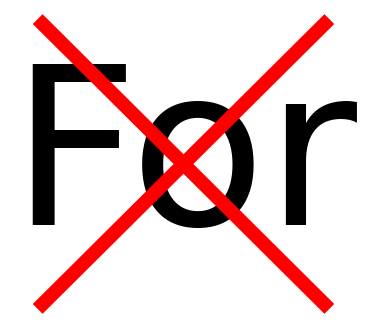

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
ax.text(0.5, 0.5, "For", fontsize=160, ha="center", va="center", zorder=0)
ax.axis("off")
ax.plot([0, 1], [0, 1], color="red", linewidth=10, zorder=1)
ax.plot([0, 1], [1, 0], color="red", linewidth=10, zorder=1)
plt.show()